# Multi-Agent Router

A **multi-agent system** that uses the **routing pattern** to direct user queries to the appropriate specialized agent.

**Architecture diagram & design doc:** [README_MULTI_AGENT_ROUTER.md](../README_MULTI_AGENT_ROUTER.md)

---

## What This Example Demonstrates

| Component | Purpose |
|-----------|---------|
| **Routing pattern** | An LLM-based router classifies each query and forwards it to the correct specialist |
| **Product QnA Agent** | ReAct agent (from Example 8) with RAG + pricing tools for laptop product questions |
| **Orders Agent** | Custom StateGraph agent (from Example 9) with query + update tools for order management |
| **Small Talk node** | Handles greetings and farewells without delegating to a specialist |
| **Agent-as-node** | `functools.partial` wraps sub-agent invocation so it works as a graph node |

---

## How It Works

1. **User asks** any question
2. **Router** classifies the query into: PRODUCT, ORDER, SMALLTALK, or END
3. **Conditional edge** routes to the appropriate agent/node
4. **Specialist agent** handles the query with its own tools and memory
5. **END** — result is returned to the user

---

## Graph

```
START → Router → [find_route] → Product_Agent  → END
                               → Orders_Agent   → END
                               → Small_Talk      → END
                               → END (fallback)
```

## Setup Model

In [1]:
import os
from pathlib import Path
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI, OpenAIEmbeddings

load_dotenv()

model = ChatOpenAI(model="gpt-4o-mini", temperature=0)
embedding = OpenAIEmbeddings(model="text-embedding-3-small")

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"

## Build the Product QnA Agent (Example 8)

A ReAct agent with two tools:
- **get_laptop_price** — CSV lookup for pricing
- **get_product_features** — RAG retrieval for specs/features

In [2]:
import pandas as pd
from langchain_core.tools import tool
from langchain_core.tools.retriever import create_retriever_tool
from langchain_core.messages import (
    AIMessage, AnyMessage, SystemMessage, HumanMessage, ToolMessage,
)
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
from langgraph.prebuilt import create_react_agent
from langgraph.checkpoint.memory import MemorySaver

product_pricing_df = pd.read_csv(DATA_DIR / "laptop_pricing.csv")


@tool
def get_laptop_price(laptop_name: str) -> int:
    """Return the price of a laptop given its name. Returns -1 if not found."""
    match_records = product_pricing_df[
        product_pricing_df["Name"].str.contains(
            "^" + laptop_name, case=False, regex=True
        )
    ]
    if len(match_records) == 0:
        return -1
    return int(match_records["Price"].iloc[0])


loader = TextLoader(str(DATA_DIR / "laptop_descriptions.txt"), encoding="utf-8")
docs = loader.load()
text_splitter = RecursiveCharacterTextSplitter(chunk_size=512, chunk_overlap=128)
splits = text_splitter.split_documents(docs)
prod_feature_store = Chroma.from_documents(documents=splits, embedding=embedding)

get_product_features = create_retriever_tool(
    prod_feature_store.as_retriever(search_kwargs={"k": 2}),
    name="get_product_features",
    description="""Search for laptop product features and specifications.
    Use when asked about: laptop features, specs, CPU, memory, storage, design,
    or which laptops are available.""",
)

product_qna_system = SystemMessage(
    content="""You are a professional chatbot that answers questions about laptops sold by your company.
To answer questions about laptops, you will ONLY use the available tools and NOT your own memory.
For product names, features, or pricing \u2014 always call the appropriate tool first.
You will handle small talk and greetings with professional, friendly responses."""
)

product_qna_agent = create_react_agent(
    model=model,
    tools=[get_laptop_price, get_product_features],
    state_modifier=product_qna_system,
    checkpointer=MemorySaver(),
)

print("Product QnA Agent ready.")

Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Product QnA Agent ready.


## Build the Orders Agent (Example 9)

A custom StateGraph agent with two tools:
- **get_order_details** — READ: Returns order info for an order ID
- **update_quantity** — WRITE: Updates laptop quantity in an order

In [3]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated
import operator

product_orders_df = pd.read_csv(DATA_DIR / "laptop_orders.csv")


@tool
def get_order_details(order_id: str) -> str:
    """Return details about a laptop order given an order ID. Returns -1 if not found."""
    match_order_df = product_orders_df[
        product_orders_df["Order ID"] == order_id
    ]
    if len(match_order_df) == 0:
        return -1
    return match_order_df.iloc[0].to_dict()


@tool
def update_quantity(order_id: str, new_quantity: int) -> bool:
    """Update the quantity of laptops ordered. Returns True if updated, False if not found."""
    global product_orders_df
    match_order_df = product_orders_df[
        product_orders_df["Order ID"] == order_id
    ]
    if len(match_order_df) == 0:
        return False
    product_orders_df.loc[
        product_orders_df["Order ID"] == order_id,
        "Quantity Ordered",
    ] = new_quantity
    return True


class OrdersAgentState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]


class OrdersAgent:
    def __init__(self, model, tools, system_prompt, debug=False):
        self.system_prompt = system_prompt
        self.debug = debug
        agent_graph = StateGraph(OrdersAgentState)
        agent_graph.add_node("orders_llm", self.call_llm)
        agent_graph.add_node("orders_tools", self.call_tools)
        agent_graph.add_conditional_edges(
            "orders_llm", self.is_tool_call,
            {True: "orders_tools", False: END},
        )
        agent_graph.add_edge("orders_tools", "orders_llm")
        agent_graph.set_entry_point("orders_llm")
        self.memory = MemorySaver()
        self.agent_graph = agent_graph.compile(checkpointer=self.memory)
        self.tools = {t.name: t for t in tools}
        self.model = model.bind_tools(tools)

    def call_llm(self, state):
        messages = state["messages"]
        if self.system_prompt:
            messages = [SystemMessage(content=self.system_prompt)] + messages
        result = self.model.invoke(messages)
        return {"messages": [result]}

    def is_tool_call(self, state):
        return len(state["messages"][-1].tool_calls) > 0

    def call_tools(self, state):
        tool_calls = state["messages"][-1].tool_calls
        results = []
        for tc in tool_calls:
            if tc["name"] not in self.tools:
                result = "Invalid tool found. Please retry."
            else:
                result = self.tools[tc["name"]].invoke(tc["args"])
            results.append(
                ToolMessage(
                    tool_call_id=tc["id"],
                    name=tc["name"],
                    content=str(result),
                )
            )
        return {"messages": results}


orders_agent = OrdersAgent(
    model,
    [get_order_details, update_quantity],
    """You are a professional chatbot that manages orders for laptops sold by our company.
The tools allow for retrieving order details as well as updating order quantity.
Do NOT reveal information about other orders than the one requested.
You will handle small talk and greetings by producing professional responses.""",
)

print("Orders Agent ready.")

Orders Agent ready.


## Using Agents as Graph Nodes

The `agent_node` helper wraps a sub-agent so it can be used as a node in the router graph.
It extracts `thread_id` from the config so each sub-agent maintains its own conversation memory.

In [4]:
import functools


def agent_node(state, agent, name, config):
    thread_id = config["metadata"]["thread_id"]
    agent_config = {"configurable": {"thread_id": thread_id}}
    result = agent.invoke(state, agent_config)
    if not isinstance(result, ToolMessage):
        final_result = AIMessage(result["messages"][-1].content)
    else:
        final_result = result
    return {"messages": [final_result]}


product_qna_node = functools.partial(
    agent_node, agent=product_qna_agent, name="Product_QnA_Agent"
)
orders_node = functools.partial(
    agent_node, agent=orders_agent.agent_graph, name="Orders_Agent"
)

## Create the Routing Agent & Chatbot

The `RouterAgent` uses an LLM to classify each user message into one of four categories:
- **PRODUCT** → route to Product QnA Agent
- **ORDER** → route to Orders Agent
- **SMALLTALK** → handle with a small-talk prompt
- **END** → fallback, end the graph

In [5]:
class RouterAgentState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]


class RouterAgent:

    def __init__(self, model, system_prompt, smalltalk_prompt, debug=False):
        self.system_prompt = system_prompt
        self.smalltalk_prompt = smalltalk_prompt
        self.model = model
        self.debug = debug

        router_graph = StateGraph(RouterAgentState)
        router_graph.add_node("Router", self.call_llm)
        router_graph.add_node("Product_Agent", product_qna_node)
        router_graph.add_node("Orders_Agent", orders_node)
        router_graph.add_node("Small_Talk", self.respond_smalltalk)

        router_graph.add_conditional_edges(
            "Router",
            self.find_route,
            {
                "PRODUCT": "Product_Agent",
                "ORDER": "Orders_Agent",
                "SMALLTALK": "Small_Talk",
                "END": END,
            },
        )

        router_graph.add_edge("Product_Agent", END)
        router_graph.add_edge("Orders_Agent", END)
        router_graph.add_edge("Small_Talk", END)
        router_graph.set_entry_point("Router")
        self.router_graph = router_graph.compile()

    def call_llm(self, state):
        messages = state["messages"]
        if self.debug:
            print(f"Router received: {messages}")
        if self.system_prompt:
            messages = [SystemMessage(content=self.system_prompt)] + messages
        result = self.model.invoke(messages)
        if self.debug:
            print(f"Router classified: {result}")
        return {"messages": [result]}

    def respond_smalltalk(self, state):
        messages = [SystemMessage(content=self.smalltalk_prompt)] + state["messages"]
        result = self.model.invoke(messages)
        return {"messages": [result]}

    def find_route(self, state):
        return state["messages"][-1].content.strip()

## Visualize the Router Graph

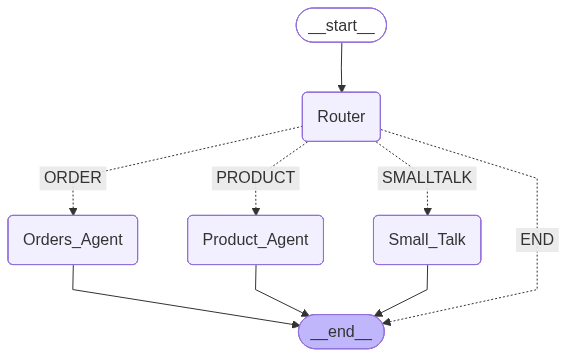

In [10]:
from IPython.display import Image

ROUTER_SYSTEM_PROMPT = """\
You are a Router that analyzes the input query and chooses one of 4 options:
SMALLTALK: If the user input is small talk, like greetings and goodbyes.
PRODUCT: If the query is a product question about laptops, like features, specifications and pricing.
ORDER: If the query is about orders for laptops, like order status, order details or update order quantity.
END: Default, when it is neither PRODUCT nor ORDER nor SMALLTALK.

The output should be ONLY one word: SMALLTALK, PRODUCT, ORDER, or END."""

SMALLTALK_PROMPT = """\
If the user request is small talk, like greetings and goodbyes, respond professionally.
Mention that you will be able to answer questions about laptop product features and \
provide order status and updates."""

router_agent = RouterAgent(
    model,
    ROUTER_SYSTEM_PROMPT,
    SMALLTALK_PROMPT,
    debug=False,
)

Image(router_agent.router_graph.get_graph().draw_mermaid_png())

## Execute Single Queries

Each query is classified by the Router and forwarded to the appropriate specialist agent.

In [11]:
import uuid

config = {"configurable": {"thread_id": str(uuid.uuid4())},
          "metadata": {"thread_id": str(uuid.uuid4())}}

messages = [HumanMessage(content="Tell me about the features of SpectraBook")]
result = router_agent.router_graph.invoke({"messages": messages}, config)
for message in result["messages"]:
    print(message.pretty_repr())

================================ Human Message =================================

Tell me about the features of SpectraBook
================================== Ai Message ==================================

PRODUCT
================================== Ai Message ==================================

The **SpectraBook S** is designed for power users and comes with the following features:

- **Processor**: Intel Core i9
- **Memory**: 64GB RAM
- **Storage**: 2TB SSD
- **Use Case**: Ideal for intensive tasks like video editing and 3D rendering, making it a workstation-class laptop.

If you have any more questions or need information about other laptops, feel free to ask!


In [12]:
config = {"configurable": {"thread_id": str(uuid.uuid4())},
          "metadata": {"thread_id": str(uuid.uuid4())}}

messages = [HumanMessage(content="What is the status of order ORD-7311?")]
result = router_agent.router_graph.invoke({"messages": messages}, config)
for message in result["messages"]:
    print(message.pretty_repr())

================================ Human Message =================================

What is the status of order ORD-7311?
================================== Ai Message ==================================

ORDER
================================== Ai Message ==================================

The status of order **ORD-7311** is as follows:

- **Product Ordered:** NanoEdge Flex
- **Quantity Ordered:** 3
- **Delivery Date:** October 19, 2024

If you need any further assistance, feel free to ask!


## Multi-Turn Conversation

A conversation that spans multiple domains:
- **Small talk** → greeting
- **Order query** → ORD-7311 details
- **Order update** → add one more laptop
- **Product query** → SpectraBook features
- **Product follow-up** → pricing (with memory)
- **Small talk** → farewell

In [13]:
user_inputs = [
    "How are you doing?",
    "Please show me the details of the order ORD-7311",
    "Can you add one more of that laptop to the order?",
    "Tell me about the features of SpectraBook laptop",
    "How much does it cost?",
    "Bye",
]

thread_id = str(uuid.uuid4())
config = {"configurable": {"thread_id": thread_id},
          "metadata": {"thread_id": thread_id}}

for user_input in user_inputs:
    print(f"{'\u2500' * 40}\nUSER  : {user_input}")
    user_message = {"messages": [HumanMessage(user_input)]}
    ai_response = router_agent.router_graph.invoke(user_message, config=config)
    print(f"AGENT : {ai_response['messages'][-1].content}\n")

────────────────────────────────────────
USER  : How are you doing?
AGENT : I'm doing well, thank you for asking! How can I assist you today? If you have any questions about laptop product features or need updates on your order status, feel free to let me know.

────────────────────────────────────────
USER  : Please show me the details of the order ORD-7311
AGENT : Here are the details for your order (ORD-7311):

- **Product Ordered:** NanoEdge Flex
- **Quantity Ordered:** 3
- **Delivery Date:** October 19, 2024

If you need any further assistance, feel free to ask!

────────────────────────────────────────
USER  : Can you add one more of that laptop to the order?
AGENT : The quantity of the NanoEdge Flex laptop in your order (ORD-7311) has been successfully updated to 4. If you need any more assistance, just let me know!

────────────────────────────────────────
USER  : Tell me about the features of SpectraBook laptop
AGENT : The SpectraBook S is designed for power users and comes wi